# Detekcja anomalii w obrazach mikroskopowych przy użyciu Autoenkodera

Celem projektu jest stworzenie systemu do automatycznego wykrywania anomalii w syntetycznych obrazach komórek. Wykorzystujemy metodę uczenia nienadzorowanego (unsupervised learning), w której model uczy się rekonstruować "zdrowe" obrazy.

**Koncepcja działania:**
1. Model trenowany jest wyłącznie na poprawnych danych.
2. Wysoki błąd rekonstrukcji (MSE) dla nowych danych sygnalizuje anomalię.
3. Wyniki weryfikowane są testem statystycznym t-Studenta.

## Architektura Modelu: Splotowy Autoenkoder (CNN)

Jako detektor wykorzystano głęboką sieć neuronową typu Autoenkoder. Składa się ona z dwóch części:
* **Enkoder:** Seria warstw konwolucyjnych (4 bloki redukujące wymiary), które kompresują obraz wejściowy $128 \times 128 \times 3$ do skompresowanej reprezentacji cech (latent space).
* **Dekoder:** Symetryczna struktura odtwarzająca obraz do oryginalnych wymiarów.

Jako funkcję błędu przyjęto `Binary Crossentropy`, a metryką detekcji anomalii jest błąd średniokwadratowy (MSE).

## Scenariusze Eksperymentalne

Przeprowadzono serię testów sprawdzających wrażliwość modelu na różne typy defektów. Dla każdego przypadku porównujemy rozkład MSE zdrowych komórek z anomaliami:

1.  **Zmiana skali:** Komórki o nienaturalnie dużym promieniu.
2.  **Zmiana koloru:** Anomalie w barwie jądra i cytoplazmy.
3.  **Zaburzony rozkład:** Zmiana algorytmu rozmieszczenia komórek (skupiska/klastry).
4.  **Deformacja kształtu:** Zastosowanie szumu Perlina do zniekształcenia krawędzi.
5.  **Anomalia złożona:** Połączenie wielu defektów jednocześnie.

## Weryfikacja Statystyczna (Test t-Studenta)

Aby potwierdzić, że wykryte różnice w błędzie rekonstrukcji (MSE) są istotne i nie wynikają z losowego doboru próby ("szczęśliwego trafu"), zastosowano **test t-Studenta dla prób niezależnych** (z poprawką Welcha na nierówną wariancję).

* **Hipoteza $H_0$:** Średni błąd rekonstrukcji dla anomalii i normy jest taki sam.
* **Wartość $p < 0.05$:** Oznacza statystycznie istotne wykrycie anomalii przez model.

In [1]:
from builders.simple_generator import generate_batch
from src.builders.image_builder import ImageGenerator
from src.utils.classes.config import GenerationConfig
from src.visualization.visualize_output import show_images

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

import keras
import cv2
import numpy as np
from scipy.stats import ttest_ind
from src.visualization.visualize_output import visualize_output
from src.models.encoder_convolutional import Encoder_conv
from tensorflow.keras.callbacks import ReduceLROnPlateau

### Eksperyment pierwszy
Eksperyment, w którym definiujemy dwa zbiory z różnicami w wielkości komórek. Utworzone zostaną dwa zbiory z różnicą w rozmiarze komórek w zbiorze testowym. Ma to na celu sprawdzenie czy istnieje
różnica w MSE.

Konfiguracja zbiorów

In [2]:
larger_cells_images_conf = GenerationConfig()
larger_cells_images_conf.axes.mean_x = 22
larger_cells_images_conf.axes.mean_y = 16
larger_cells_images_conf.axes.std_x = 6
larger_cells_images_conf.distribution.radius = 40

larger_cells = ImageGenerator(larger_cells_images_conf)

Utworzenie zbioru i sprawdzenie wyników

Generated 9 centers
Generated 8 centers
Generated 10 centers
Generated 9 centers
Generated 9 centers
Generated 9 centers
Generated 8 centers
Generated 8 centers
Generated 8 centers
Generated 7 centers
Generated 11 centers
Generated 8 centers
Generated 7 centers
Generated 9 centers
Generated 10 centers
Generated 9 centers
Generated 8 centers
Generated 7 centers
Generated 9 centers
Generated 9 centers
Generated 9 centers
Generated 10 centers
Generated 10 centers
Generated 9 centers
Generated 9 centers
Generated 9 centers
Generated 9 centers
Generated 9 centers
Generated 8 centers
Generated 9 centers
Generated 10 centers
Generated 9 centers
Generated 10 centers
Generated 9 centers
Generated 9 centers
Generated 9 centers
Generated 8 centers
Generated 9 centers
Generated 9 centers
Generated 10 centers
Generated 8 centers
Generated 9 centers
Generated 9 centers
Generated 8 centers
Generated 8 centers
Generated 10 centers
Generated 9 centers
Generated 9 centers
Generated 9 centers
Generated 7

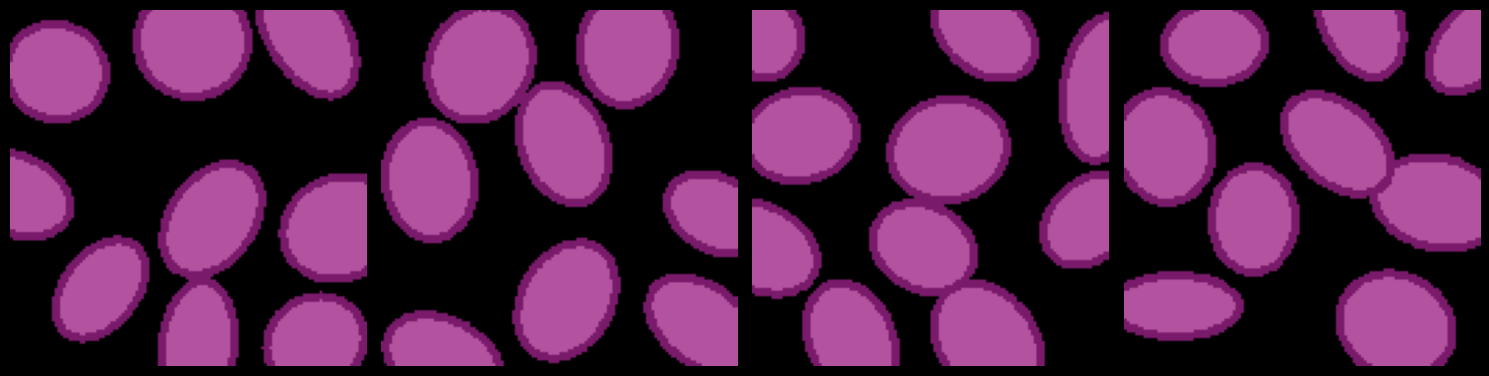

In [3]:
larger_cells_set = larger_cells.build_batch(2000)

show_images(larger_cells_set[:4])

### Eksperyment drugi
Eksperyment ma na celu sprawdzenie błędu MSE w sytuacji gdy zmienia się kolor komórek.

Konfiguracja komórki

In [4]:
different_colors_conf = GenerationConfig()
different_colors_conf.nucleus.base_color = (134, 80, 34)
different_colors_conf.nucleus.border_color = (29, 40, 182)

different_colors_cells = ImageGenerator(different_colors_conf)

Utworzenie zbioru i sprawdzenie wyników

Generated 15 centers
Generated 14 centers
Generated 15 centers
Generated 15 centers
Generated 14 centers
Generated 17 centers
Generated 14 centers
Generated 12 centers
Generated 14 centers
Generated 15 centers
Generated 15 centers
Generated 16 centers
Generated 15 centers
Generated 18 centers
Generated 15 centers
Generated 16 centers
Generated 15 centers
Generated 16 centers
Generated 15 centers
Generated 16 centers
Generated 15 centers
Generated 14 centers
Generated 17 centers
Generated 15 centers
Generated 16 centers
Generated 14 centers
Generated 14 centers
Generated 13 centers
Generated 16 centers
Generated 16 centers
Generated 14 centers
Generated 15 centers
Generated 17 centers
Generated 15 centers
Generated 15 centers
Generated 16 centers
Generated 15 centers
Generated 15 centers
Generated 14 centers
Generated 15 centers
Generated 14 centers
Generated 13 centers
Generated 14 centers
Generated 14 centers
Generated 14 centers
Generated 15 centers
Generated 14 centers
Generated 16 

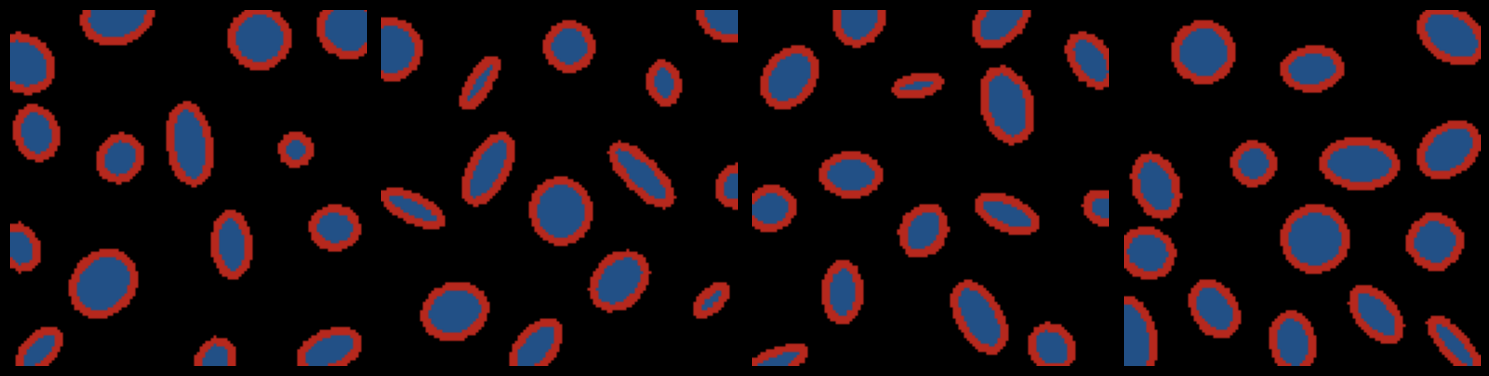

In [5]:
different_color_cells_set = different_colors_cells.build_batch(2000)

show_images(different_color_cells_set[:4])

### Eksperyment trzeci
W eksperymencie sprawdzone zostanie wpływ rozkładu komórek na błąd MSE.

Konfiguracja komórki

In [6]:
distribution_conf = GenerationConfig()
distribution_conf.distribution.algorithm = "gaussian"

gaussian_dist_cells = ImageGenerator(distribution_conf)

Utworzenie zbioru i sprawdzenie wyników

Generated 10 centers
Generated 10 centers
Generated 10 centers
Generated 10 centers
Generated 10 centers
Generated 10 centers
Generated 10 centers
Generated 10 centers
Generated 10 centers
Generated 10 centers
Generated 10 centers
Generated 10 centers
Generated 10 centers
Generated 10 centers
Generated 10 centers
Generated 10 centers
Generated 10 centers
Generated 10 centers
Generated 10 centers
Generated 10 centers
Generated 10 centers
Generated 10 centers
Generated 10 centers
Generated 10 centers
Generated 10 centers
Generated 10 centers
Generated 10 centers
Generated 10 centers
Generated 10 centers
Generated 10 centers
Generated 10 centers
Generated 10 centers
Generated 10 centers
Generated 10 centers
Generated 10 centers
Generated 10 centers
Generated 10 centers
Generated 10 centers
Generated 10 centers
Generated 10 centers
Generated 10 centers
Generated 10 centers
Generated 10 centers
Generated 10 centers
Generated 10 centers
Generated 10 centers
Generated 10 centers
Generated 10 

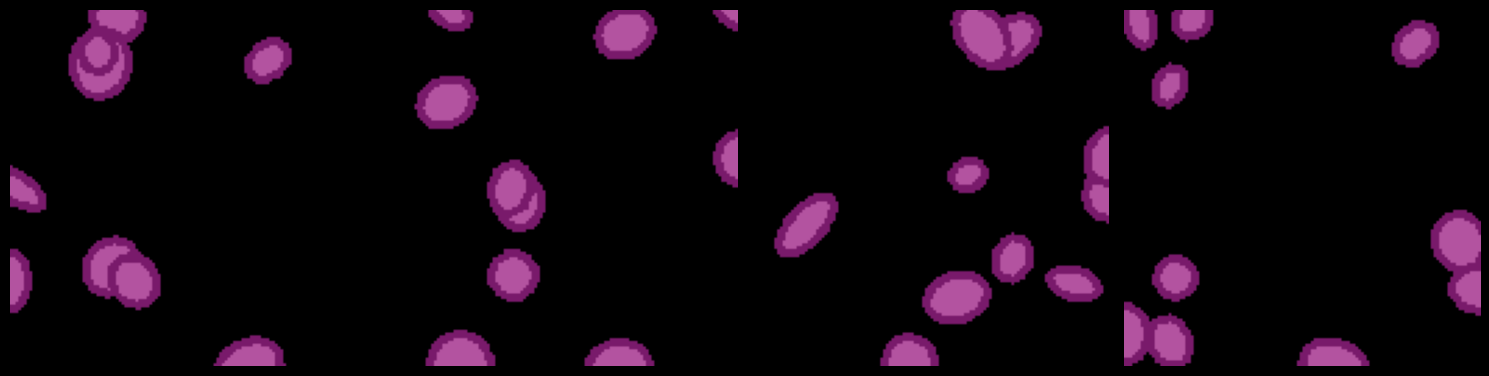

In [7]:
gaussian_dist_set = gaussian_dist_cells.build_batch(2000)

show_images(gaussian_dist_set[:4])

### Eksperyment czwarty
Sprawdzenie wpływu zniekształcenia kształtu komórek za pomocą szumu perlina na wynik MSE.

In [8]:
perlin_noise_conf = (ImageGenerator()
                     .with_perlin_noise(True))

Utworzenie zbioru i sprawdzenie wyników.

Generated 16 centers
Generated 16 centers
Generated 15 centers
Generated 17 centers
Generated 16 centers
Generated 16 centers
Generated 15 centers
Generated 15 centers
Generated 14 centers
Generated 14 centers
Generated 15 centers
Generated 13 centers
Generated 16 centers
Generated 15 centers
Generated 17 centers
Generated 17 centers
Generated 17 centers
Generated 16 centers
Generated 15 centers
Generated 13 centers
Generated 13 centers
Generated 16 centers
Generated 14 centers
Generated 14 centers
Generated 16 centers
Generated 16 centers
Generated 15 centers
Generated 16 centers
Generated 16 centers
Generated 15 centers
Generated 14 centers
Generated 16 centers
Generated 14 centers
Generated 14 centers
Generated 16 centers
Generated 17 centers
Generated 15 centers
Generated 14 centers
Generated 15 centers
Generated 17 centers
Generated 16 centers
Generated 13 centers
Generated 15 centers
Generated 15 centers
Generated 14 centers
Generated 13 centers
Generated 17 centers
Generated 13 

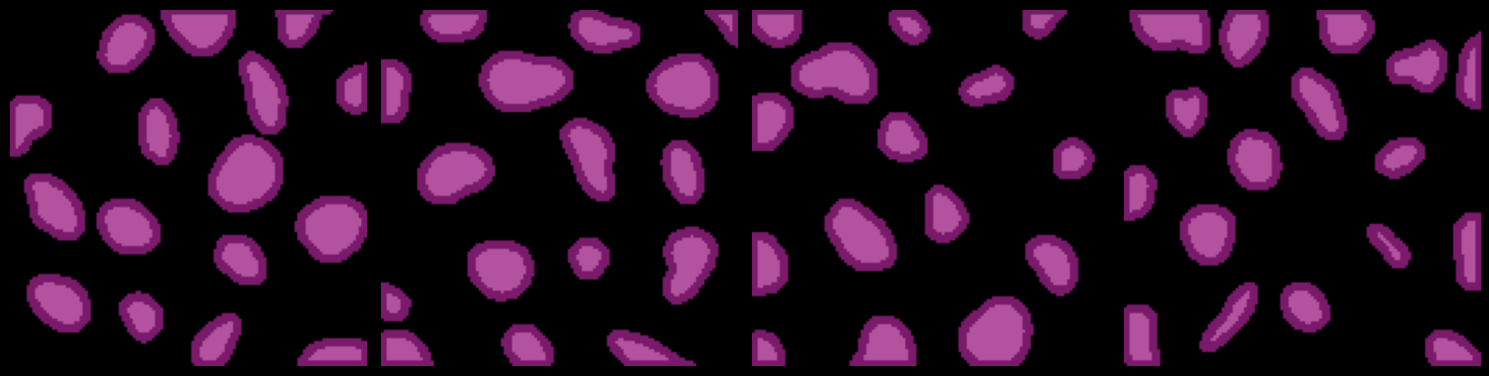

In [9]:
perlin_noise_set = perlin_noise_conf.build_batch(2000)

show_images(perlin_noise_set[:4])

### Eksperyment piąty

Połączenie wszystkich dotychczasowych eksperymentów.


In [10]:
various_conf = (ImageGenerator()
                .with_axes_config(16,18)
                .with_perlin_noise(True)
                .with_clustered_distribution(deviation=1)
                .with_cancer_cells(color=(23,190,40),
                                   border_color=(80,23,22)))

Utworzenie zbioru i sprawdzenie wyników.

Generated 7 centers
Generated 6 centers
Generated 9 centers
Generated 7 centers
Generated 8 centers
Generated 3 centers
Generated 7 centers
Generated 8 centers
Generated 7 centers
Generated 8 centers
Generated 4 centers
Generated 6 centers
Generated 8 centers
Generated 7 centers
Generated 6 centers
Generated 4 centers
Generated 6 centers
Generated 6 centers
Generated 5 centers
Generated 3 centers
Generated 5 centers
Generated 9 centers
Generated 5 centers
Generated 3 centers
Generated 7 centers
Generated 5 centers
Generated 6 centers
Generated 6 centers
Generated 6 centers
Generated 6 centers
Generated 7 centers
Generated 6 centers
Generated 5 centers
Generated 7 centers
Generated 4 centers
Generated 6 centers
Generated 8 centers
Generated 7 centers
Generated 5 centers
Generated 8 centers
Generated 3 centers
Generated 7 centers
Generated 5 centers
Generated 9 centers
Generated 5 centers
Generated 5 centers
Generated 5 centers
Generated 7 centers
Generated 7 centers
Generated 3 centers


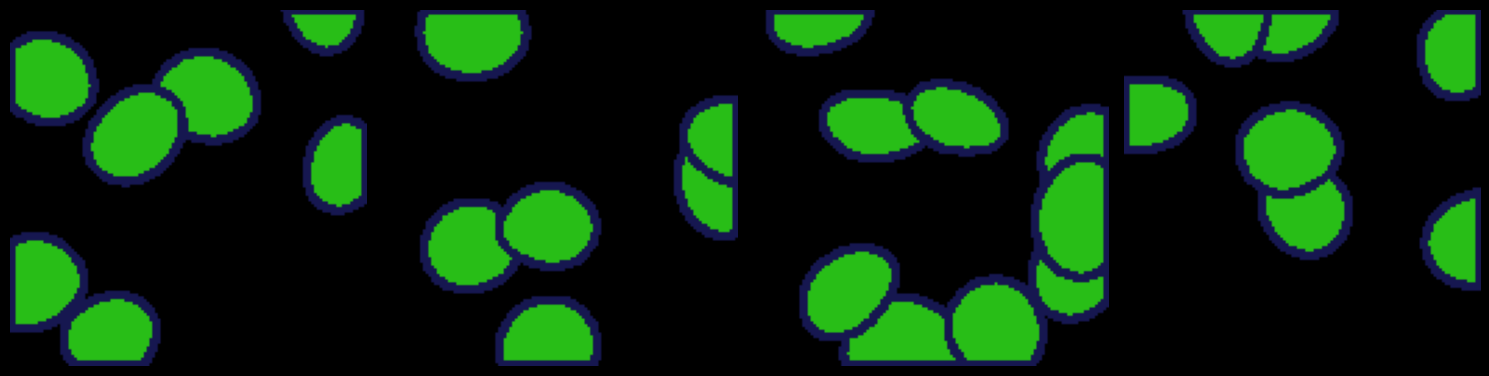

In [11]:
various_conf_set = various_conf.build_batch(2000)
show_images(various_conf_set[:4])

## Enkoder

Przygorowanie zbioru treningowego, walidacyjnego oraz testowego

Generated 15 centers
Generated 16 centers
Generated 15 centers
Generated 14 centers
Generated 14 centers
Generated 14 centers
Generated 15 centers
Generated 16 centers
Generated 15 centers
Generated 14 centers
Generated 13 centers
Generated 14 centers
Generated 15 centers
Generated 15 centers
Generated 16 centers
Generated 15 centers
Generated 13 centers
Generated 16 centers
Generated 14 centers
Generated 16 centers
Generated 15 centers
Generated 15 centers
Generated 16 centers
Generated 16 centers
Generated 15 centers
Generated 17 centers
Generated 15 centers
Generated 15 centers
Generated 16 centers
Generated 15 centers
Generated 15 centers
Generated 17 centers
Generated 15 centers
Generated 15 centers
Generated 15 centers
Generated 15 centers
Generated 14 centers
Generated 14 centers
Generated 12 centers
Generated 16 centers
Generated 12 centers
Generated 14 centers
Generated 15 centers
Generated 15 centers
Generated 14 centers
Generated 16 centers
Generated 16 centers
Generated 15 

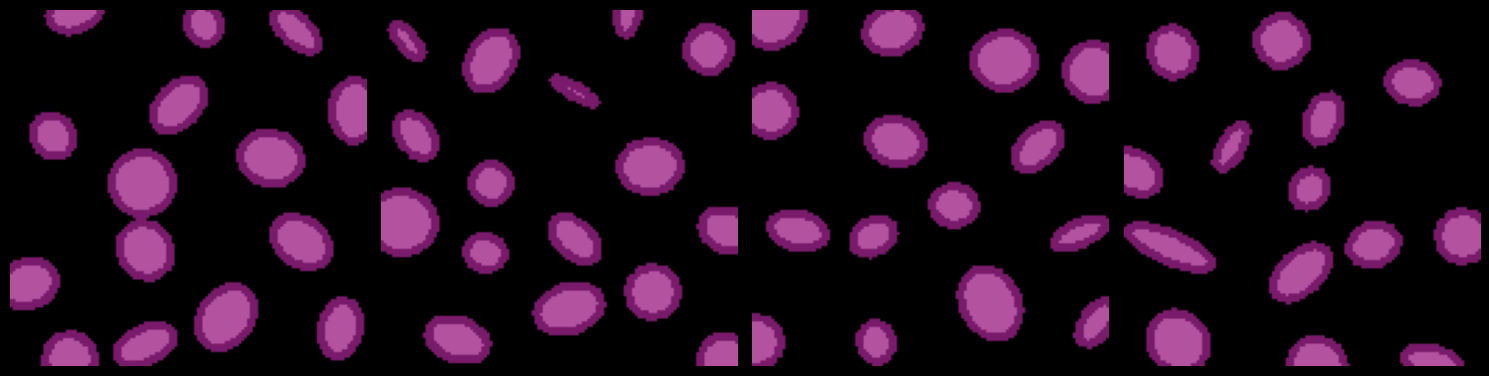

In [12]:
training_set = generate_batch(5000)

show_images(training_set[:4])

Generated 14 centers
Generated 15 centers
Generated 18 centers
Generated 14 centers
Generated 15 centers
Generated 16 centers
Generated 15 centers
Generated 15 centers
Generated 14 centers
Generated 14 centers
Generated 15 centers
Generated 17 centers
Generated 14 centers
Generated 16 centers
Generated 15 centers
Generated 14 centers
Generated 14 centers
Generated 14 centers
Generated 16 centers
Generated 15 centers
Generated 15 centers
Generated 15 centers
Generated 16 centers
Generated 15 centers
Generated 16 centers
Generated 14 centers
Generated 15 centers
Generated 15 centers
Generated 16 centers
Generated 14 centers
Generated 14 centers
Generated 14 centers
Generated 16 centers
Generated 17 centers
Generated 13 centers
Generated 17 centers
Generated 14 centers
Generated 16 centers
Generated 15 centers
Generated 13 centers
Generated 14 centers
Generated 16 centers
Generated 16 centers
Generated 14 centers
Generated 15 centers
Generated 15 centers
Generated 18 centers
Generated 16 

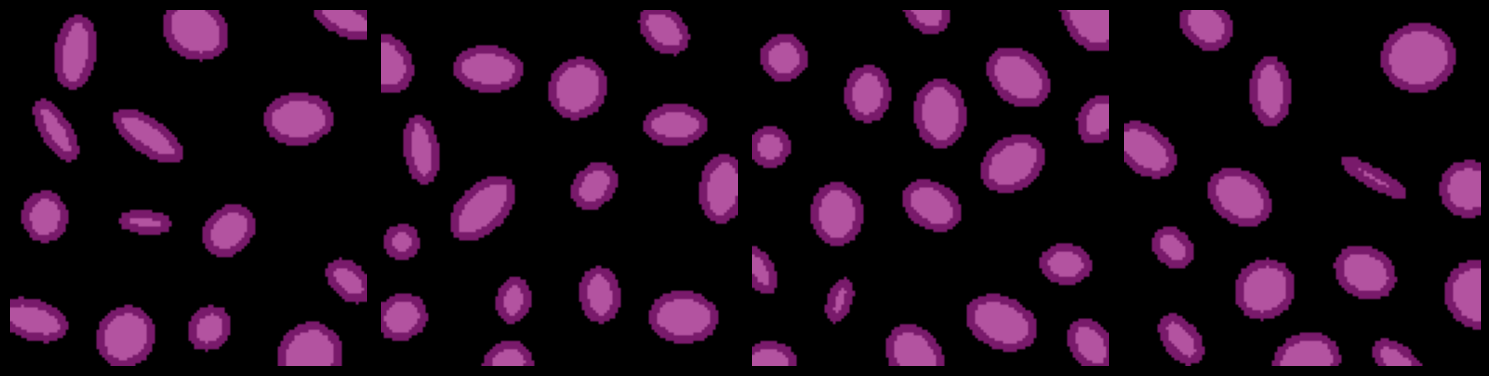

In [13]:
validation_set = generate_batch(1000)

show_images(validation_set[:4])

Generated 14 centers
Generated 17 centers
Generated 14 centers
Generated 15 centers
Generated 14 centers
Generated 15 centers
Generated 16 centers
Generated 17 centers
Generated 14 centers
Generated 18 centers
Generated 15 centers
Generated 15 centers
Generated 15 centers
Generated 16 centers
Generated 13 centers
Generated 16 centers
Generated 15 centers
Generated 13 centers
Generated 15 centers
Generated 12 centers
Generated 16 centers
Generated 15 centers
Generated 15 centers
Generated 14 centers
Generated 16 centers
Generated 16 centers
Generated 15 centers
Generated 14 centers
Generated 14 centers
Generated 14 centers
Generated 15 centers
Generated 16 centers
Generated 12 centers
Generated 15 centers
Generated 18 centers
Generated 13 centers
Generated 16 centers
Generated 14 centers
Generated 16 centers
Generated 17 centers
Generated 17 centers
Generated 17 centers
Generated 14 centers
Generated 13 centers
Generated 15 centers
Generated 17 centers
Generated 16 centers
Generated 15 

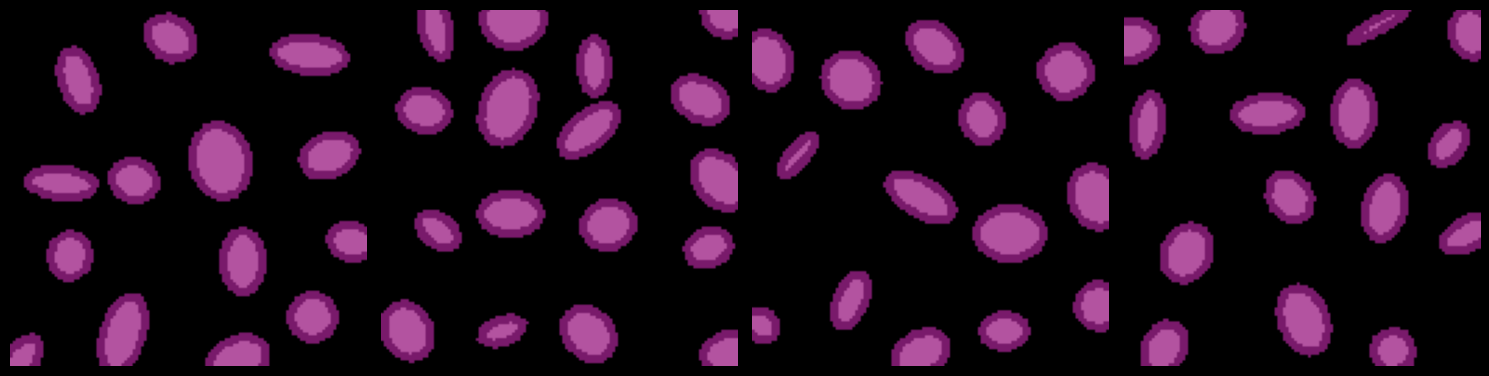

In [14]:
test_set = generate_batch(2000)

show_images(test_set[:4])

Przygotowanie danych dla enkodera

In [15]:
def preprocess(data_list):
    return np.array(data_list, dtype='float32') / 255.

In [16]:
x_test_data = preprocess(test_set)
x_val_data = preprocess(validation_set)
x_traning_data = preprocess(training_set)

Inplementacja enkodera

In [17]:
enkoder = Encoder_conv()

enkoder.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy', 'mse'])

early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=6,
    min_delta=0.0001,
    restore_best_weights=True
)
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    min_lr=0.00001,
    verbose=1
)

history = enkoder.fit(
    x_traning_data, x_traning_data,
    epochs=50,
    shuffle=True,
    callbacks=[reduce_lr, early_stopping],
    validation_data=(x_val_data, x_val_data),
    verbose=1
)
print(f"\nTrening zakończony po {len(history.history['loss'])} epokach.")

Epoch 1/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 20s 111ms/step - accuracy: 0.5330 - loss: 0.1924 - mse: 0.0120 - val_accuracy: 0.3152 - val_loss: 0.1570 - val_mse: 0.0025 - learning_rate: 0.0010
Epoch 2/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 17s 109ms/step - accuracy: 0.3395 - loss: 0.1559 - mse: 0.0021 - val_accuracy: 0.4888 - val_loss: 0.1539 - val_mse: 0.0017 - learning_rate: 0.0010
Epoch 3/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 18s 115ms/step - accuracy: 0.5909 - loss: 0.1535 - mse: 0.0014 - val_accuracy: 0.6558 - val_loss: 0.1524 - val_mse: 0.0012 - learning_rate: 0.0010
Epoch 4/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 18s 116ms/step - accuracy: 0.6924 - loss: 0.1526 - mse: 0.0012 - val_accuracy: 0.7269 - val_loss: 0.1517 - val_mse: 0.0011 - learning_rate: 0.0010
Epoch 5/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 18s 114ms/step - accuracy: 0.7425 - loss: 0.1521 - mse: 0.0010 - val_accuracy: 0.7576 - val_loss: 0.1513 - val_mse: 9.3691e-04 - learning_rate: 0.0010
Epoch 6/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 18s 115ms/step - accu

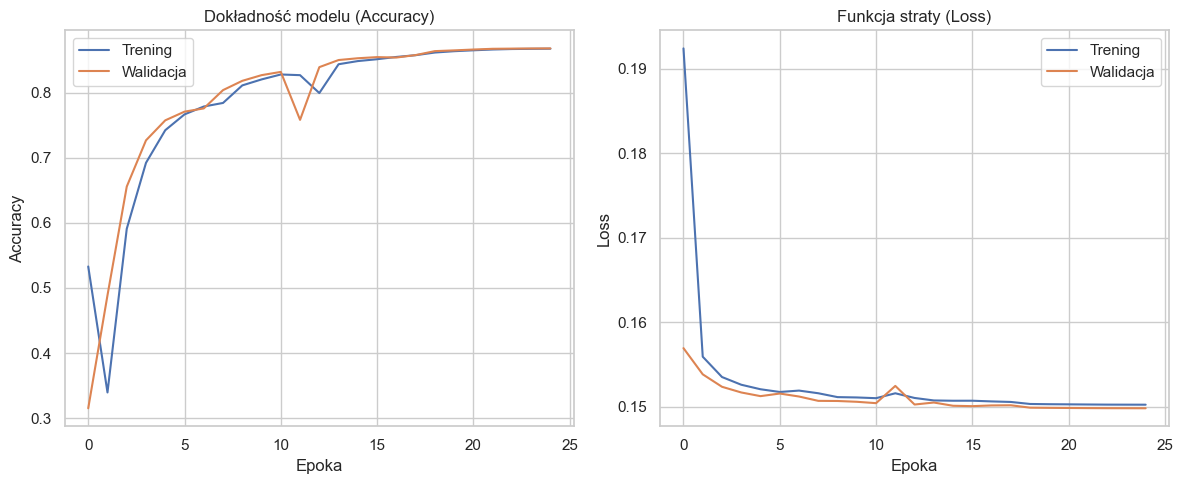

In [18]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Trening')
plt.plot(history.history['val_accuracy'], label='Walidacja')
plt.title('Dokładność modelu (Accuracy)')
plt.xlabel('Epoka')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Trening')
plt.plot(history.history['val_loss'], label='Walidacja')
plt.title('Funkcja straty (Loss)')
plt.xlabel('Epoka')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()

63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step
MSE Normal: 0.000574


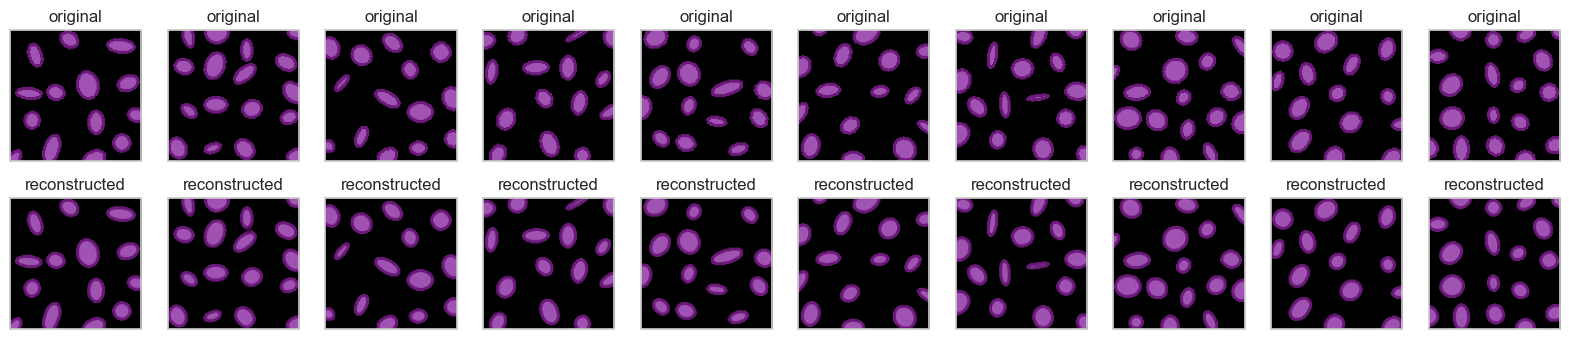

In [19]:
decoded_test = enkoder.predict(x_test_data)
mse_test = enkoder.evaluate(x_test_data, x_test_data, verbose=0)[2]

print(f"MSE Normal: {mse_test:.6f}")

visualize_output(x_test_data, decoded_test, 10)

Wykres błedu MSE

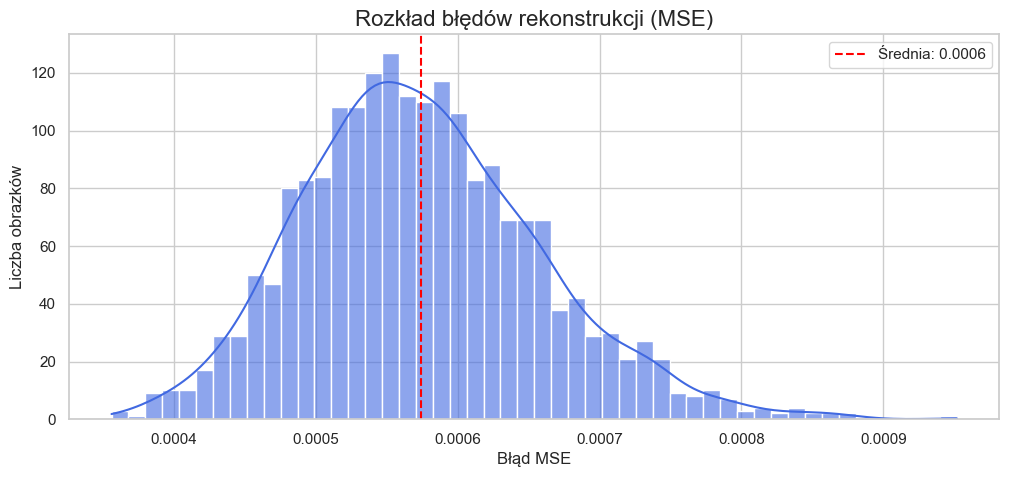

In [21]:
mse_test_per_image = np.mean(np.square(x_test_data - decoded_test), axis=(1, 2, 3))

plt.figure(figsize=(12, 5))

sns.histplot(mse_test_per_image, bins=50, kde=True, color="royalblue", alpha=0.6)

mean_val_test = np.mean(mse_test_per_image)
plt.axvline(mean_val_test, color='red', linestyle='--', label=f'Średnia: {mean_val_test:.4f}')

plt.title("Rozkład błędów rekonstrukcji (MSE)", fontsize=16)
plt.xlabel("Błąd MSE", fontsize=12)
plt.ylabel("Liczba obrazków", fontsize=12)

plt.legend()
plt.show()

In [22]:
test = [{'Eksperyment': 'MSE test', 'Wynik': mse_test}]

mse_dataset = pd.DataFrame(test, columns=['Eksperyment', 'Wynik'])
mse_dataset

,Eksperyment,Wynik
0,MSE test,0.000574


### Wyniki eksperymentu pierwszego

63/63 - 2s - 34ms/step - accuracy: 0.8711 - loss: 0.3320 - mse: 0.0010
MSE Large:  0.001049


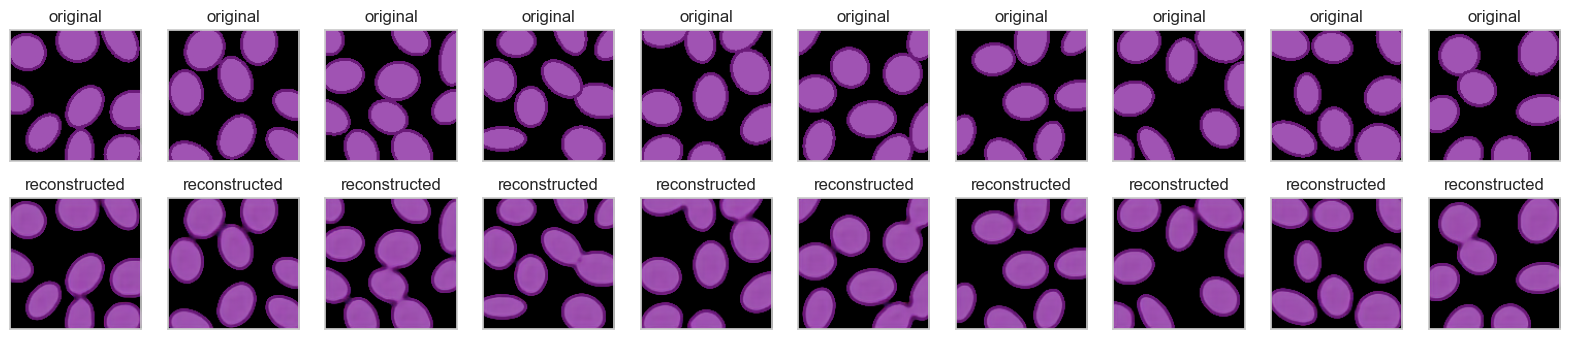

In [23]:
x_large_cells_data = preprocess(larger_cells_set)

decoded_large_cells = enkoder.predict(x_large_cells_data, verbose = 0)
mse_large = enkoder.evaluate(x_large_cells_data, x_large_cells_data, verbose=2)[2]

print(f"MSE Large:  {mse_large:.6f}")

visualize_output(x_large_cells_data, decoded_large_cells, 10)

In [24]:
mse_test_per_image

array([0.00055791, 0.00076511, 0.00050144, ..., 0.00071079, 0.00065949,
       0.00063114], shape=(2000,), dtype=float32)

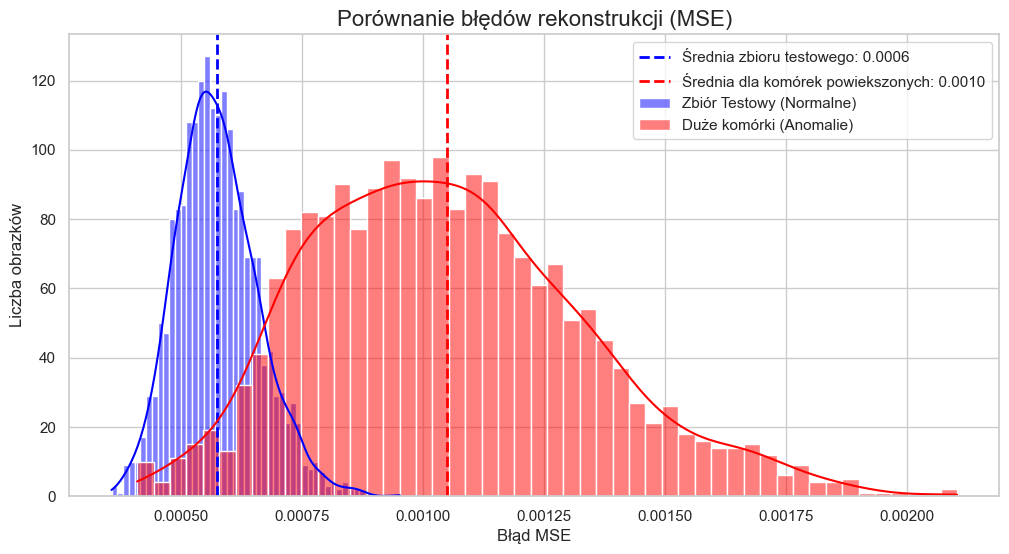

In [25]:
mse_large_per_image = np.mean(np.square(x_large_cells_data - decoded_large_cells), axis=(1, 2, 3))

plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")
sns.histplot(mse_test_per_image, bins=50, kde=True,
             color='blue', alpha=0.5, label='Zbiór Testowy (Normalne)')
plt.axvline(mean_val_test, color='blue', linestyle='--', label=f'Średnia zbioru testowego: {mean_val_test:.4f}',linewidth=2)
sns.histplot(mse_large_per_image, bins=50, kde=True,
             color='red', alpha=0.5, label='Duże komórki (Anomalie)')
mean_val_larger_cells = np.mean(mse_large_per_image)

plt.axvline(mean_val_larger_cells, color='red', linestyle='--', label=f'Średnia dla komórek powiekszonych: {mean_val_larger_cells:.4f}',linewidth=2)
plt.title("Porównanie błędów rekonstrukcji (MSE)", fontsize=16)
plt.xlabel("Błąd MSE", fontsize=12)
plt.ylabel("Liczba obrazków", fontsize=12)

plt.legend()
plt.show()

**Hipoteza zerowa**

Zakładamy, że wartość średniego błędu MSE dla normalnych komórek jest taka sama jak dla anomalii. (Wariant pesymistyczny)

**Hipoteza alternatywna**

Średni błąd Mse dla anomalii jest większy niż komórek normalnych

**Aby wyeliminować podejrzenie losowości w wynikach MSE zastosowano test t-studenta dla błędu MSE.**

Interpretacja:
* Jeżeli p_value jest mniejsze niż 0.05 oznacza to, że szansa na to, że wynik uzyskaliśmy przez losowe zbiegnięcie się danych jest mniejsza niż 0.0001% i jest praktycznie niemożliwa. Odrzucamy hipotezę o szczęściu w losowaniu obrazów i model działa.
* Jeżeli p_value jest większe od 0.05 oznacza to, że istnieje ryzyko, że różnica wynika z przypadku. Pesymistyczna hipoteza zerowa mogła mieć miejsce.

In [26]:
t_stat1, p_val1 = ttest_ind(mse_large_per_image, mse_test_per_image,
                          equal_var=False, alternative='greater')

print(f"Statystyka t: {t_stat1:.4f}")
print(f"P-value: {p_val1:.30f}")

Statystyka t: 71.8435
P-value: 0.000000000000000000000000000000


In [27]:
larger_cells = [{'Eksperyment': 'MSE for larger cells', 'Wynik': mse_large}]

mse_dataset = pd.concat([mse_dataset, pd.DataFrame(larger_cells)],ignore_index=True)
mse_dataset

,Eksperyment,Wynik
0,MSE test,0.000574
1,MSE for larger cells,0.001049


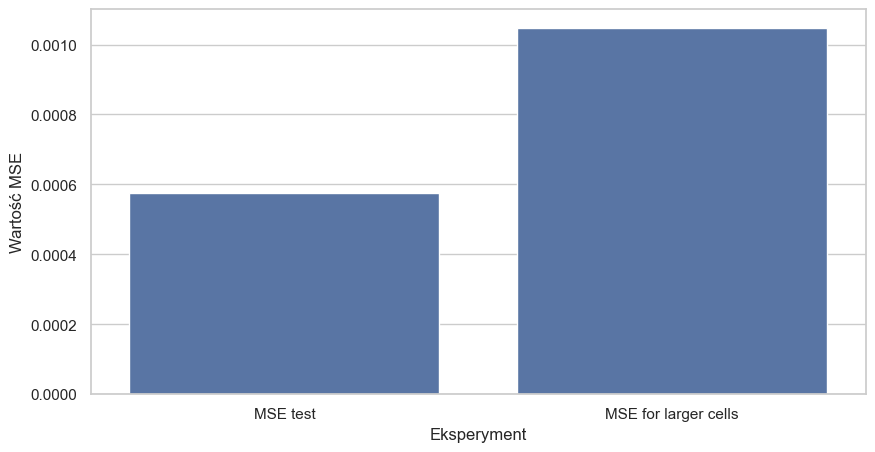

In [28]:
plt.figure(figsize=(10, 5))
sns.barplot(data=mse_dataset, y='Wynik',x='Eksperyment')
plt.ylabel("Wartość MSE")
plt.show()

### Wyniki eksperymentu drugiego

63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.7239 - loss: 0.1683 - mse: 0.0174
MSE of cells with different colors:  0.017419


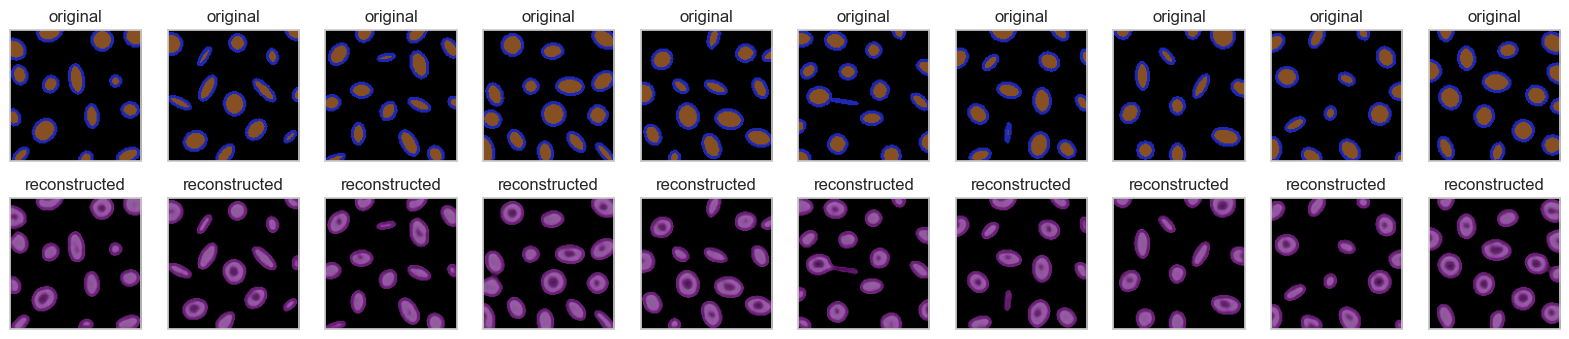

In [29]:
x_diff_color_cells_data = preprocess(different_color_cells_set)

decoded_diff_colors_cells = enkoder.predict(x_diff_color_cells_data,verbose = 0)
mse_color = enkoder.evaluate(x_diff_color_cells_data, x_diff_color_cells_data, verbose=1)[2]

print(f"MSE of cells with different colors:  {mse_color:.6f}")

visualize_output(x_diff_color_cells_data, decoded_diff_colors_cells, 10)

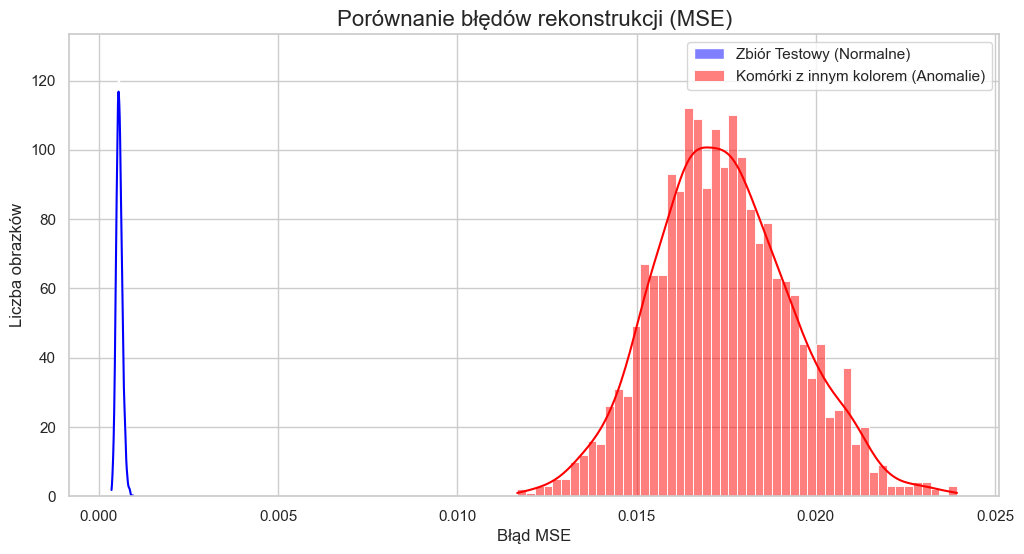

In [30]:
mse_diff_color_per_image = np.mean(np.square(x_diff_color_cells_data - decoded_diff_colors_cells), axis=(1, 2, 3))

plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")
sns.histplot(mse_test_per_image, bins=50, kde=True,
             color='blue', alpha=0.5, label='Zbiór Testowy (Normalne)')

sns.histplot(mse_diff_color_per_image, bins=50, kde=True,
             color='red', alpha=0.5, label='Komórki z innym kolorem (Anomalie)')

plt.title("Porównanie błędów rekonstrukcji (MSE)", fontsize=16)
plt.xlabel("Błąd MSE", fontsize=12)
plt.ylabel("Liczba obrazków", fontsize=12)

plt.legend()
plt.show()

In [31]:
t_stat2, p_val2 = ttest_ind(mse_diff_color_per_image, mse_test_per_image,
                          equal_var=False, alternative='greater')

print(f"Statystyka t: {t_stat2:.4f}")
print(f"P-value: {p_val2:.30f}")

Statystyka t: 390.4319
P-value: 0.000000000000000000000000000000


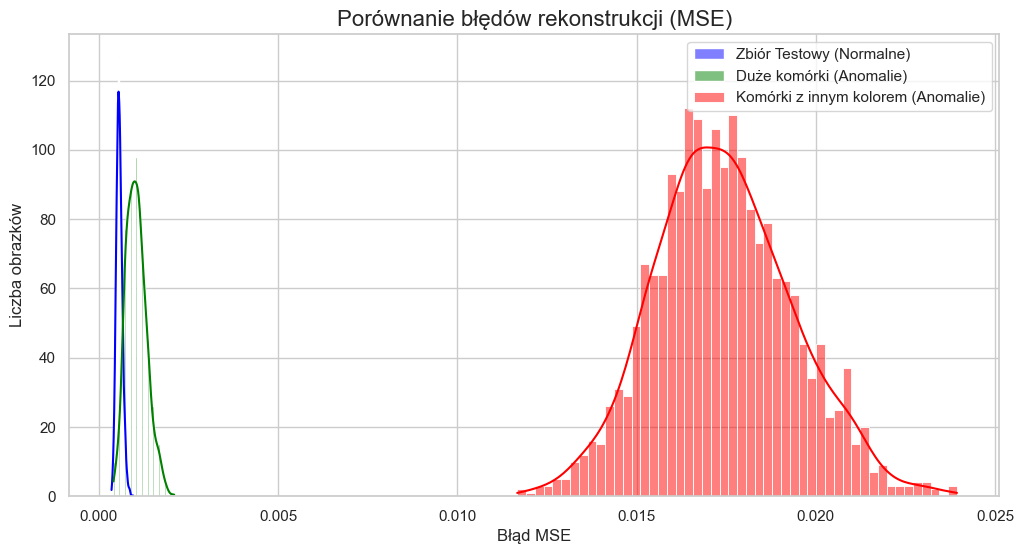

In [32]:
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")
sns.histplot(mse_test_per_image, bins=50, kde=True,
             color='blue', alpha=0.5, label='Zbiór Testowy (Normalne)')
sns.histplot(mse_large_per_image, bins=50, kde=True,
             color='green', alpha=0.5, label='Duże komórki (Anomalie)')
sns.histplot(mse_diff_color_per_image, bins=50, kde=True,
             color='red', alpha=0.5, label='Komórki z innym kolorem (Anomalie)')

plt.title("Porównanie błędów rekonstrukcji (MSE)", fontsize=16)
plt.xlabel("Błąd MSE", fontsize=12)
plt.ylabel("Liczba obrazków", fontsize=12)

plt.legend()
plt.show()

In [33]:
diff_color_cells = [{'Eksperyment': 'MSE with different color', 'Wynik': mse_color}]

mse_dataset = pd.concat([mse_dataset, pd.DataFrame(diff_color_cells)],ignore_index=True)
mse_dataset

,Eksperyment,Wynik
0,MSE test,0.000574
1,MSE for larger cells,0.001049
2,MSE with different color,0.017419


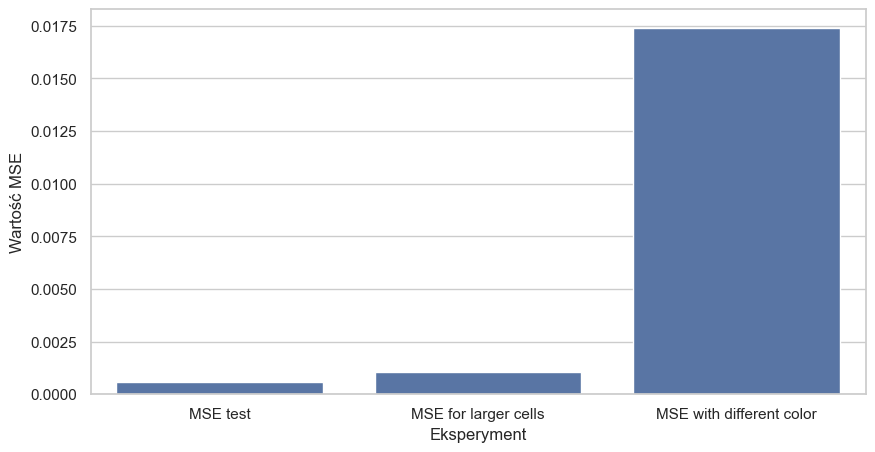

In [34]:
plt.figure(figsize=(10, 5))
sns.barplot(data=mse_dataset, y='Wynik',x='Eksperyment')
plt.ylabel("Wartość MSE")
plt.show()

### Wyniki eksperymentu trzeciego

63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step
MSE with Gauss's distribution:  0.000601


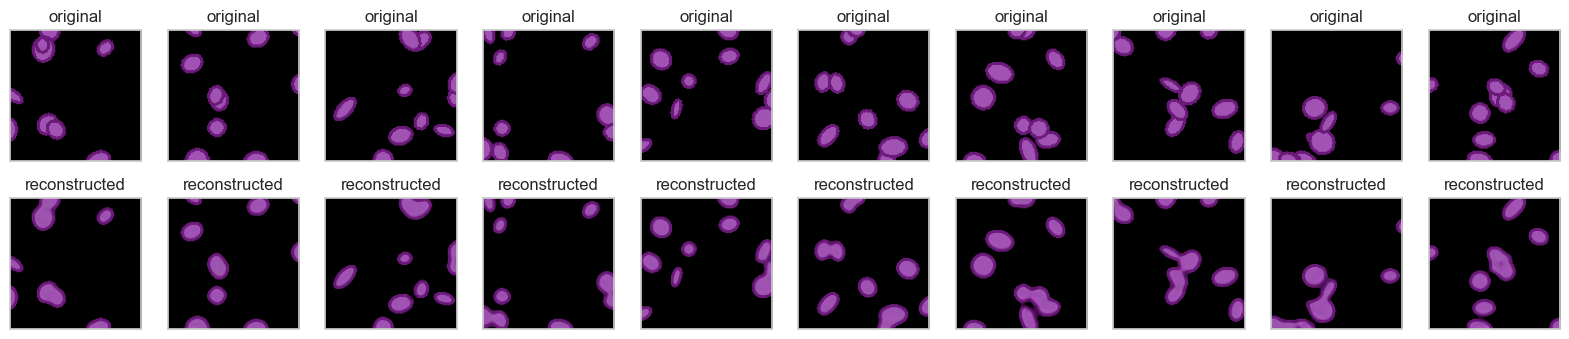

In [35]:
x_gaussian_dist_data = preprocess(gaussian_dist_set)

decoded_gaussian_dist_cells = enkoder.predict(x_gaussian_dist_data)
mse_gaussian = enkoder.evaluate(x_gaussian_dist_data,x_gaussian_dist_data,verbose = 0)[2]

print(f"MSE with Gauss's distribution:  {mse_gaussian:.6f}")

visualize_output(x_gaussian_dist_data, decoded_gaussian_dist_cells, 10)

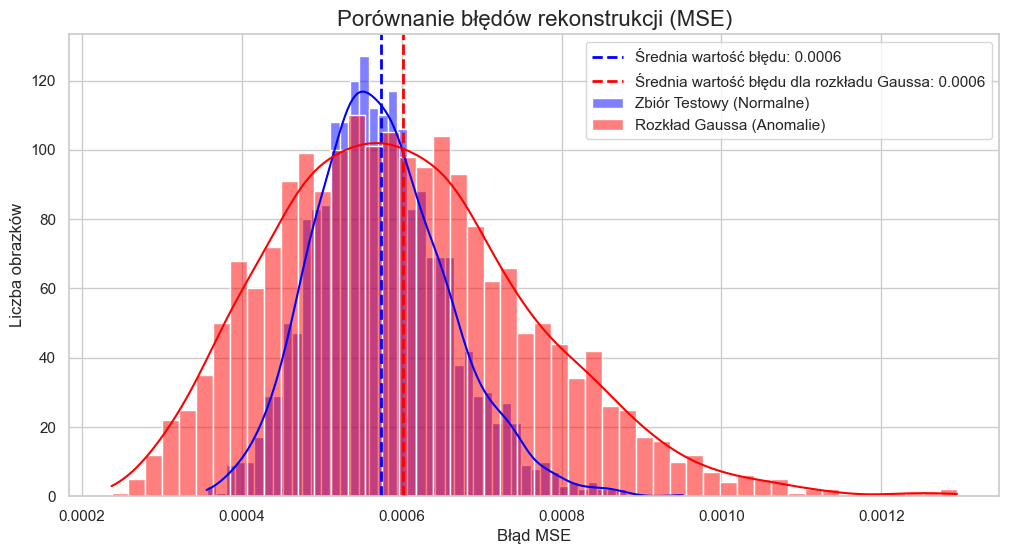

In [36]:
mse_gaussian_per_image = np.mean(np.square(x_gaussian_dist_data - decoded_gaussian_dist_cells), axis=(1, 2, 3))

plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")
sns.histplot(mse_test_per_image,
             bins=50, kde=True,
             color='blue',
             alpha=0.5,
             label='Zbiór Testowy (Normalne)')
plt.axvline(mean_val_test,
            color='blue',
            linestyle='--',
            linewidth=2,
            label=f'Średnia wartość błędu: {mean_val_test:.4f}')


mean_val_gauss_dist = np.mean(mse_gaussian_per_image)
sns.histplot(mse_gaussian_per_image,
             bins=50,
             kde=True,
             color='red',
             alpha=0.5,
             label='Rozkład Gaussa (Anomalie)')
plt.axvline(mean_val_gauss_dist,
            color='red',
            linestyle='--',
            linewidth=2,
            label= f'Średnia wartość błędu dla rozkładu Gaussa: {mean_val_gauss_dist:.4f}')

plt.title("Porównanie błędów rekonstrukcji (MSE)", fontsize=16)
plt.xlabel("Błąd MSE", fontsize=12)
plt.ylabel("Liczba obrazków", fontsize=12)

plt.legend()
plt.show()

In [37]:
t_stat3, p_val3 = ttest_ind(mse_gaussian_per_image, mse_test_per_image,
                          equal_var=False, alternative='greater')

print(f"Statystyka t: {t_stat3:.4f}")
print(f"P-value: {p_val3:.30f}")

Statystyka t: 6.6505
P-value: 0.000000000017287277231887341897


In [38]:
gaussian_dist = [{'Eksperyment': "MSE with Gauss's distribution", 'Wynik': mse_gaussian}]

mse_dataset = pd.concat([mse_dataset, pd.DataFrame(gaussian_dist)],ignore_index=True)
mse_dataset

,Eksperyment,Wynik
0,MSE test,0.000574
1,MSE for larger cells,0.001049
2,MSE with different color,0.017419
3,MSE with Gauss's distribution,0.000601


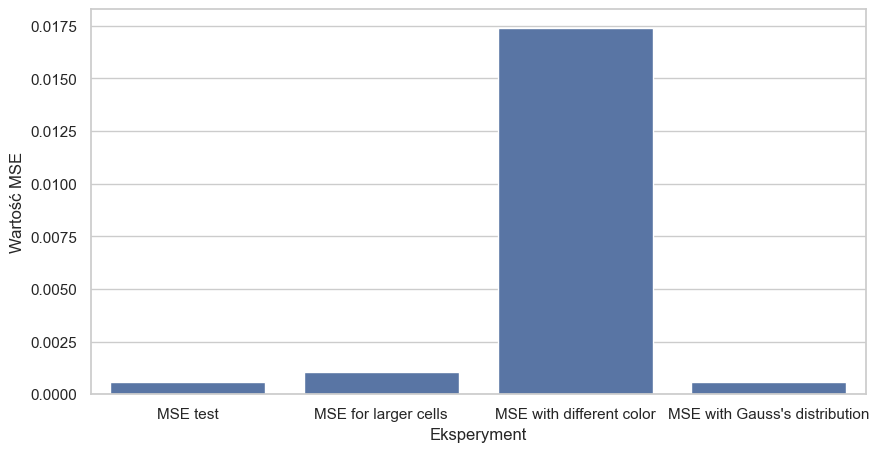

In [39]:
plt.figure(figsize=(10, 5))
sns.barplot(data=mse_dataset, y='Wynik',x='Eksperyment')
plt.ylabel("Wartość MSE")
plt.show()

Wyniki eksperymentu czwartego

63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step
MSE of cells with Perlin Noise:  0.000883


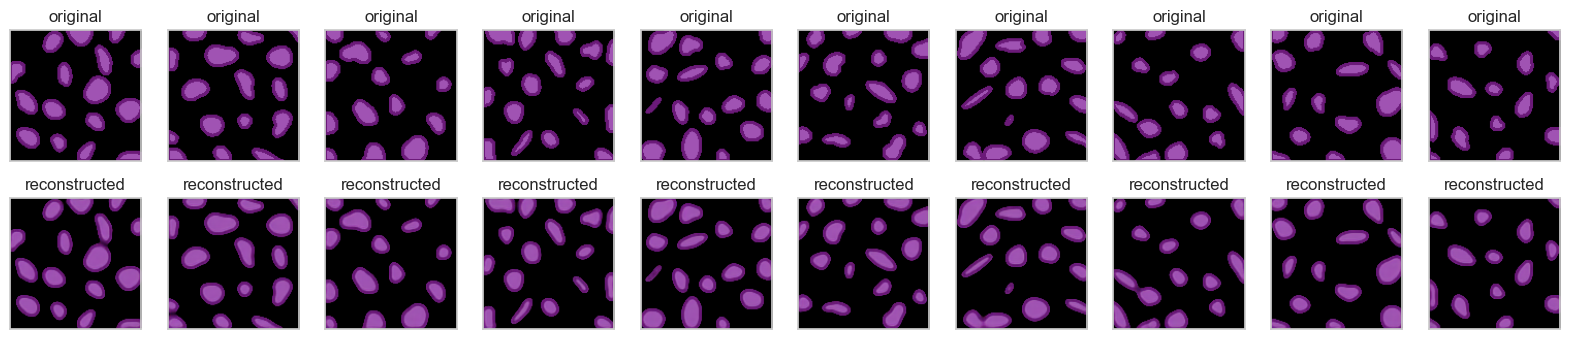

In [40]:
x_perlin_data = preprocess(perlin_noise_set)

decoded_perlin_noise_cells = enkoder.predict(x_perlin_data)
mse_perlin = enkoder.evaluate(x_perlin_data,x_perlin_data,verbose = 0)[2]

print(f"MSE of cells with Perlin Noise:  {mse_perlin:.6f}")

visualize_output(x_perlin_data, decoded_perlin_noise_cells, 10)

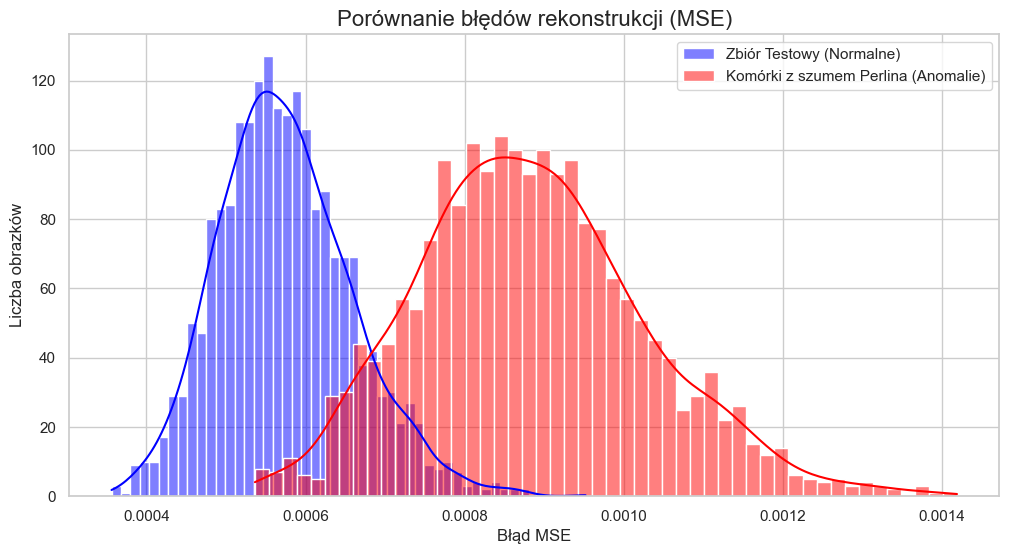

In [41]:
mse_perlin_per_image = np.mean(np.square(x_perlin_data - decoded_perlin_noise_cells), axis=(1, 2, 3))

plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")
sns.histplot(mse_test_per_image, bins=50, kde=True,
             color='blue', alpha=0.5, label='Zbiór Testowy (Normalne)')

sns.histplot(mse_perlin_per_image, bins=50, kde=True,
             color='red', alpha=0.5, label='Komórki z szumem Perlina (Anomalie)')

plt.title("Porównanie błędów rekonstrukcji (MSE)", fontsize=16)
plt.xlabel("Błąd MSE", fontsize=12)
plt.ylabel("Liczba obrazków", fontsize=12)

plt.legend()
plt.show()

In [42]:
t_stat4, p_val4 = ttest_ind(mse_perlin_per_image, mse_test_per_image,
                          equal_var=False, alternative='greater')

print(f"Statystyka t: {t_stat4:.4f}")
print(f"P-value: {p_val4:.30f}")

Statystyka t: 82.9291
P-value: 0.000000000000000000000000000000


In [43]:
perlin_cells = [{'Eksperyment': "MSE with Perlin Noise", 'Wynik': mse_perlin}]

mse_dataset = pd.concat([mse_dataset, pd.DataFrame(perlin_cells)], ignore_index=True)
mse_dataset

,Eksperyment,Wynik
0,MSE test,0.000574
1,MSE for larger cells,0.001049
2,MSE with different color,0.017419
3,MSE with Gauss's distribution,0.000601
4,MSE with Perlin Noise,0.000883


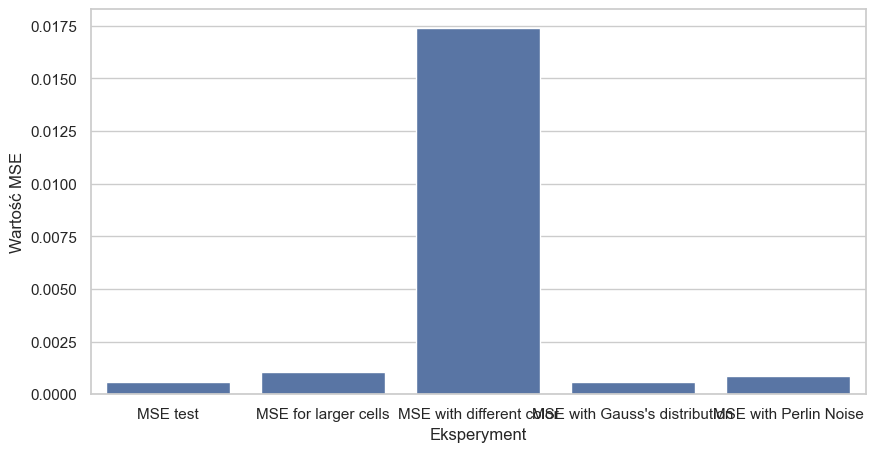

In [44]:
plt.figure(figsize=(10, 5))
sns.barplot(data=mse_dataset, y='Wynik',x='Eksperyment')
plt.ylabel("Wartość MSE")
plt.show()

Wyniki eksperymentu piątego

63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step
MSE with various configuration:  0.037965


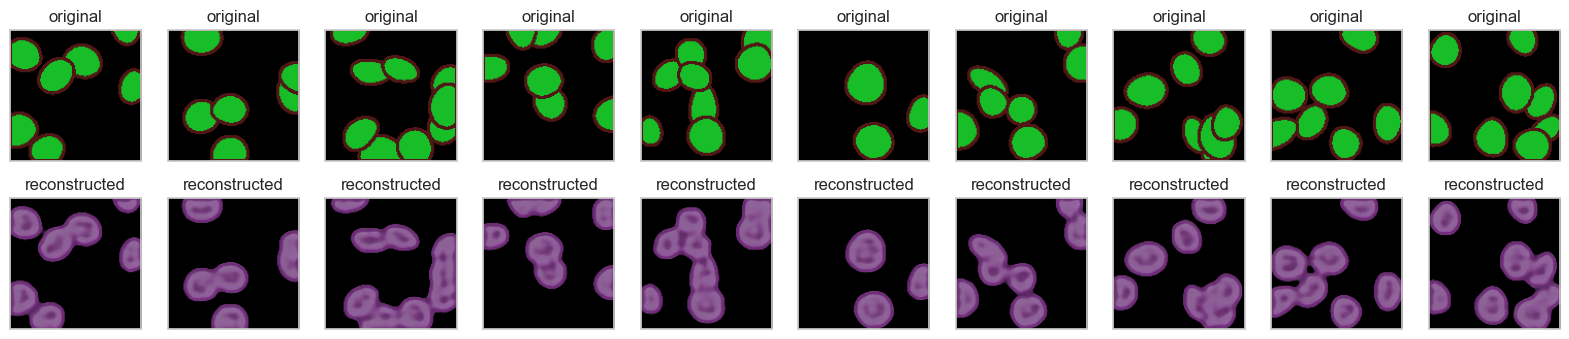

In [45]:
x_various_conf_data = preprocess(various_conf_set)

decoded_various_conf = enkoder.predict(x_various_conf_data)
mse_various_conf = enkoder.evaluate(x_various_conf_data,x_various_conf_data,verbose = 0)[2]

print(f"MSE with various configuration:  {mse_various_conf:.6f}")

visualize_output(x_various_conf_data, decoded_various_conf, 10)

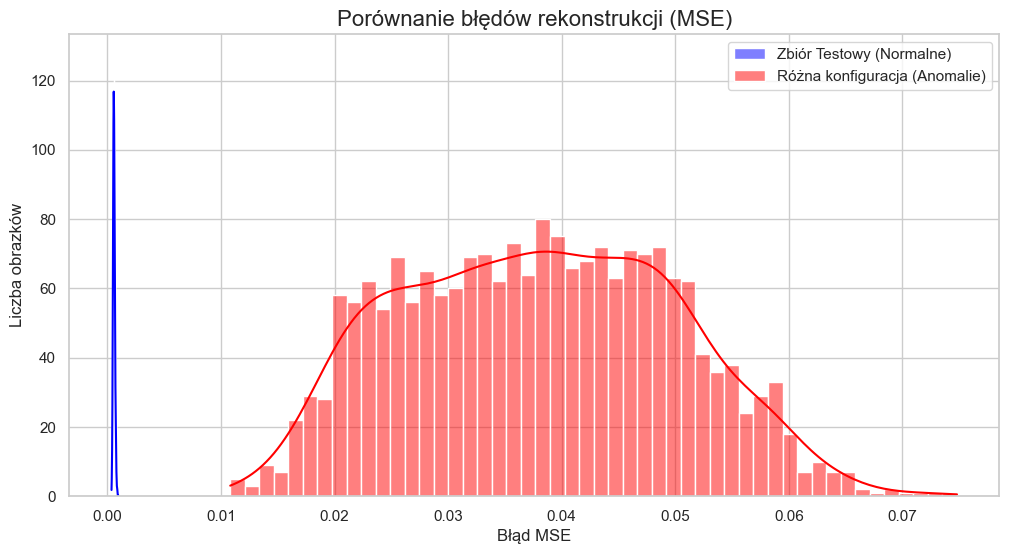

In [46]:
mse_various_per_image = np.mean(np.square(x_various_conf_data - decoded_various_conf), axis=(1, 2, 3))

plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")
sns.histplot(mse_test_per_image, bins=50, kde=True,
             color='blue', alpha=0.5, label='Zbiór Testowy (Normalne)')

sns.histplot(mse_various_per_image, bins=50, kde=True,
             color='red', alpha=0.5, label='Różna konfiguracja (Anomalie)')

plt.title("Porównanie błędów rekonstrukcji (MSE)", fontsize=16)
plt.xlabel("Błąd MSE", fontsize=12)
plt.ylabel("Liczba obrazków", fontsize=12)

plt.legend()
plt.show()

In [47]:
t_stat5, p_val5 = ttest_ind(mse_various_per_image, mse_test_per_image,
                          equal_var=False, alternative='greater')

print(f"Statystyka t: {t_stat5:.4f}")
print(f"P-value: {p_val5:.30f}")

Statystyka t: 140.1537
P-value: 0.000000000000000000000000000000


In [48]:
various_conf = [{'Eksperyment': "MSE with various configuration", 'Wynik': mse_various_conf}]

mse_dataset = pd.concat([mse_dataset, pd.DataFrame(various_conf)],ignore_index=True)
mse_dataset

,Eksperyment,Wynik
0,MSE test,0.000574
1,MSE for larger cells,0.001049
2,MSE with different color,0.017419
3,MSE with Gauss's distribution,0.000601
4,MSE with Perlin Noise,0.000883
5,MSE with various configuration,0.037965


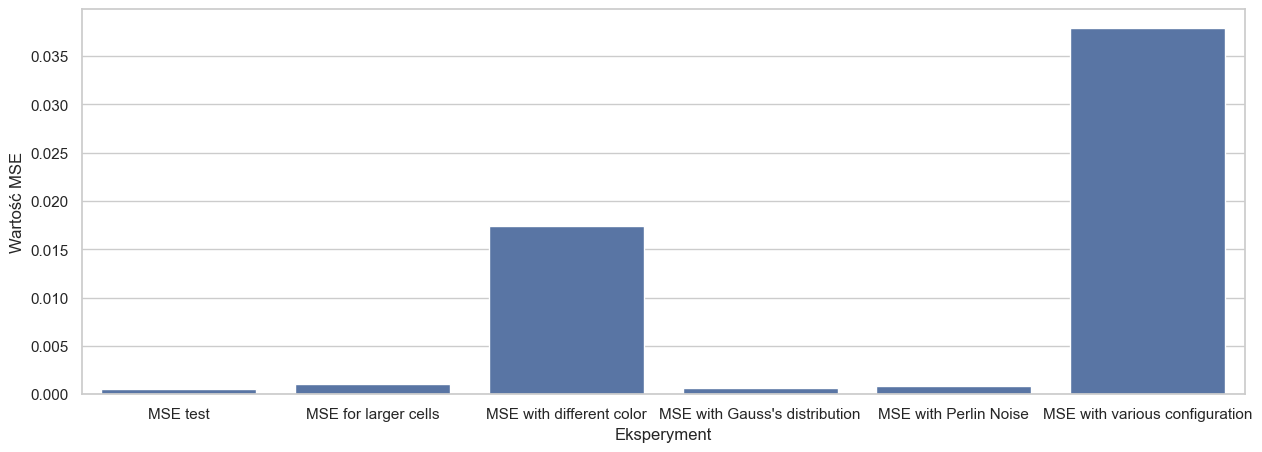

In [49]:
plt.figure(figsize=(15, 5))
sns.barplot(data=mse_dataset, y='Wynik',x='Eksperyment')
plt.ylabel("Wartość MSE")
plt.show()

Inplementacja Metody Otsu do automatycznego wyznaczania progu wykrycia komórek

In [167]:
import random
from src.functions.otsu_function import detect_anomaly_otsu_mse

otsu_thresholds = []

for i in range(len(x_perlin_data)):
    input_data = x_perlin_data[i]
    output_data = decoded_perlin_noise_cells[i]

    calculated_threshold, anomaly_mask, error_map = detect_anomaly_otsu_mse(input_data,output_data)
    otsu_thresholds.append([calculated_threshold, anomaly_mask, error_map])




In [186]:
all_thresholds = [x[0] for x in otsu_thresholds]

In [200]:
print(f'Liczba uzyskanych progów: {len(all_thresholds)}')

Liczba uzyskanych progów: 2000


In [201]:
print(f'średni próg: {np.mean(all_thresholds)}')
print(f'najmniejsza wartość progu: {np.min(all_thresholds)}')
print(f'największa wartość progu: {np.max(all_thresholds)}')
print(f'std: {np.std(all_thresholds)}')

średni próg: 4.286
najmniejsza wartość progu: 3.0
największa wartość progu: 11.0
std: 0.5433267893266446


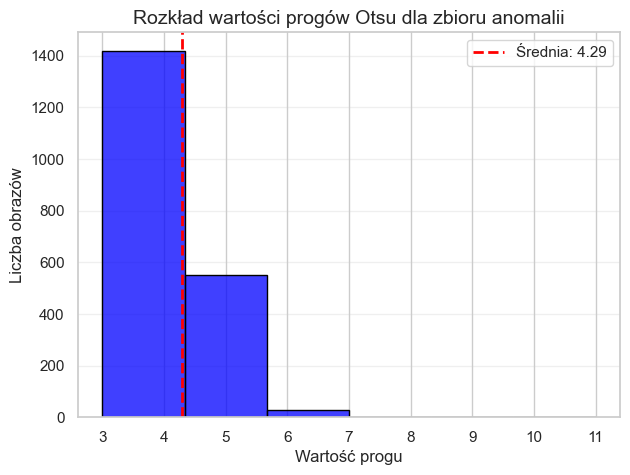

In [202]:
plt.figure(figsize=(7, 5))
sns.histplot(x=all_thresholds, bins=6, kde=False,color='blue', edgecolor='black')
plt.axvline(np.mean(all_thresholds), color='red', linestyle='--', linewidth=2, label=f'Średnia: {np.mean(all_thresholds):.2f}')

plt.title('Rozkład wartości progów Otsu dla zbioru anomalii', fontsize=14)
plt.xlabel('Wartość progu')
plt.ylabel('Liczba obrazów', fontsize=12)
plt.legend()
plt.grid(axis='y', alpha=0.3)

In [214]:
idx = random.randint(0, len(otsu_thresholds)-1)

curr_org = x_perlin_data[idx]
curr_dec = decoded_perlin_noise_cells[idx]

idx_thresh = otsu_thresholds[idx][0]
idx_mask =  otsu_thresholds[idx][1]
idx_err = otsu_thresholds[idx][2]

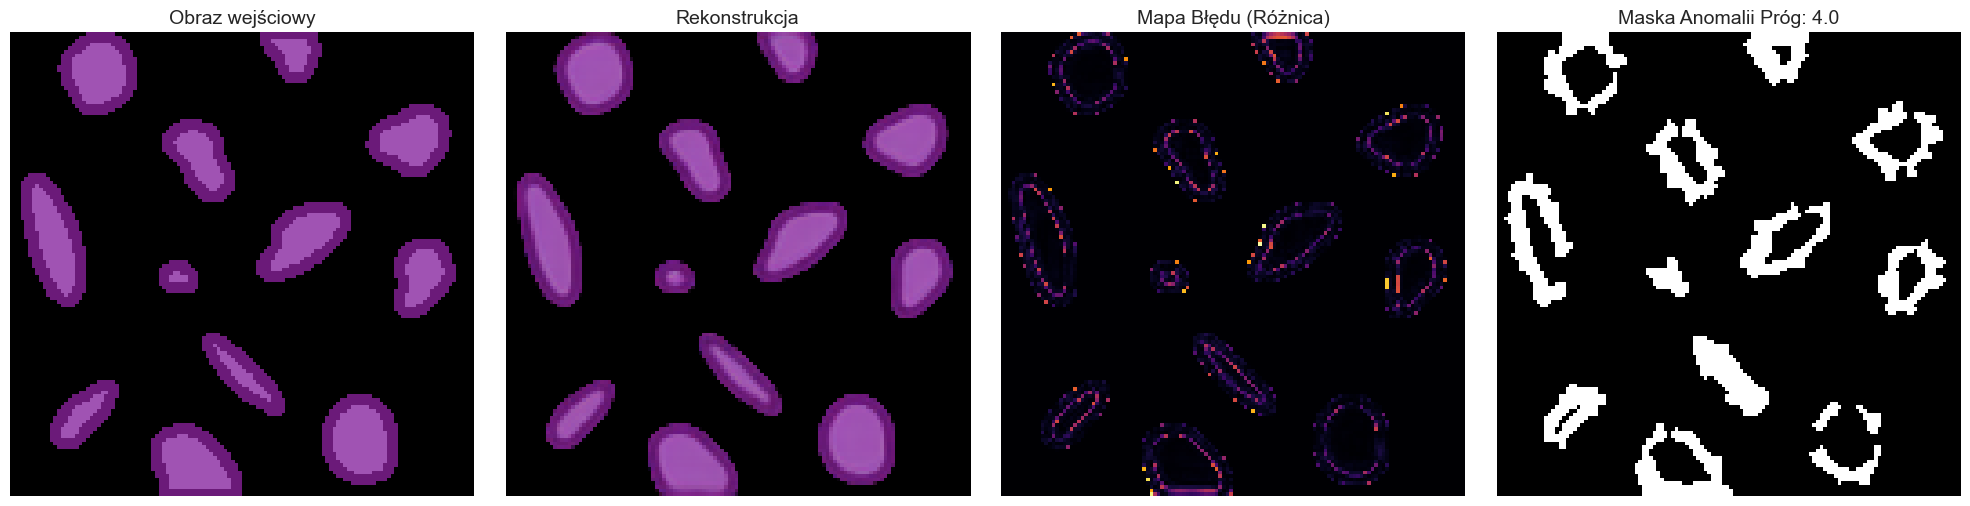

In [221]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(20, 5))
plt.subplot(1,4,1)
plt.title("Obraz wejściowy", fontsize=14)
plt.imshow(curr_org)
plt.axis('off')


plt.subplot(1,4,2)
plt.title('Rekonstrukcja', fontsize=14)
plt.imshow(curr_dec)
plt.axis('off')


plt.subplot(1,4,3)
plt.imshow(idx_err, cmap='inferno')
plt.title("Mapa Błędu (Różnica)", fontsize=14)
plt.axis('off')

plt.subplot(1,4,4)

plt.imshow(curr_org)
plt.imshow(idx_mask, cmap='gray')

plt.title(f"Maska Anomalii Próg: {idx_thresh:.1f}", fontsize=14)
plt.axis('off')

plt.tight_layout()
plt.show()

implementacja algorytmu ze strony dokumentacji cv2

In [205]:
input = x_perlin_data[idx]

image = cv2.GaussianBlur(input, (5,5),0)

In [206]:
bins_num = 256

hist, bin_edges = np.histogram(image, bins=bins_num)

bin_mids = (bin_edges[:-1] + bin_edges[1:]) / 2.

weight1 = np.cumsum(hist)
weight2 = np.cumsum(hist[::-1])[::-1]

mean1 = np.cumsum(hist * bin_mids) / weight1
mean2 = (np.cumsum((hist * bin_mids)[::-1]) / weight2[::-1])[::-1]

inter_class_variance = weight1[:-1] * weight2[1:] * (mean1[:-1] - mean2[1:]) ** 2

index_of_max_val = np.argmax(inter_class_variance)

threshold = bin_mids[:-1][index_of_max_val]
print("Otsu's algorithm implementation thresholding result: ", threshold)

Otsu's algorithm implementation thresholding result:  0.2481541
